# Laboratory Task 4 — Regression Using PyTorch

**Understanding Deep Learning**


The laboratory task requires: MSE Loss, 2 fully connected layers, batch size of 8, SGD optimizer, and 1000 training epochs.

> The source laboratory task does not prescribe a specific regression dataset. For this implementation, the Scikit-learn Diabetes regression dataset is used because it provides a reproducible continuous-target regression problem without requiring an external download.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Reproducibility

Setting random seeds ensures that results are consistent across runs.

In [2]:
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

## Device Configuration

Following the original lesson, we check whether a GPU is available and use it if possible.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


---
## 1. Load and Understand the Regression Data

The Diabetes dataset contains 10 baseline clinical measurements (age, sex, BMI, blood pressure, and six blood serum measurements) for 442 patients. The target is a quantitative measure of disease progression one year after the baseline measurements.

In [4]:
# Load the dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nFeature names: {diabetes.feature_names}")
print(f"\nTarget range: {y.min():.0f} to {y.max():.0f}")

Feature matrix shape: (442, 10)
Target vector shape:  (442,)

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target range: 25 to 346


In [5]:
# Display several rows as a DataFrame for readability
df = pd.DataFrame(X, columns=diabetes.feature_names)
df["target"] = y
df.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


---
## 2. Prepare Input and Target

We separate the features and target, then reshape the target to `(n, 1)` so its shape matches the model's `(batch_size, 1)` regression output when `nn.MSELoss()` is used. PyTorch does not require every regression target to be two-dimensional; the reshape is used here to keep the target dimensions compatible with this model's output.

The data is then split into training and testing sets using an 80/20 split.

In [6]:
# Reshape target to (n, 1) for PyTorch regression
y = y.reshape(-1, 1)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 353
Testing samples:  89


---
## 3. Feature and Target Scaling

**Feature scaling.** Standardizing the input features to approximately zero mean and unit variance helps gradient-based optimization operate on comparable feature scales. The feature scaler is fitted only on the training data and then applied to the test data to avoid information leakage.

**Target scaling.** The Diabetes target values are on a much larger numerical scale than the standardized input features. The target is therefore standardized during training to improve the numerical stability and convergence behavior of SGD and to make optimization less sensitive to the learning-rate choice. Target standardization is useful here, but it is not mathematically required for every regression problem; an unscaled target can still be trained with suitable optimization settings.

The target scaler is fitted only on `y_train`. Predictions are inverse-transformed back to the original Diabetes target units before the final evaluation metrics are calculated.

In [7]:
scaler = StandardScaler()

# Fit on training data only, then transform both sets
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Scale the target to stabilize SGD training
target_scaler = StandardScaler()
y_train = target_scaler.fit_transform(y_train)

print("Feature scaling complete.")
print(f"Training feature mean (should be ~0): {X_train.mean(axis=0).round(4)}")
print(f"Training target mean:  {y_train.mean():.4f}")
print(f"Training target std:   {y_train.std():.4f}")

Feature scaling complete.
Training feature mean (should be ~0): [ 0.  0. -0.  0. -0. -0.  0.  0.  0. -0.]
Training target mean:  -0.0000
Training target std:   1.0000


---
## 4. Convert to PyTorch Tensors

PyTorch requires data as tensors. We use `float32`, which is the standard precision for neural network training.

In [8]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print(f"X_train tensor shape: {X_train_tensor.shape}")
print(f"y_train tensor shape: {y_train_tensor.shape}")

X_train tensor shape: torch.Size([353, 10])
y_train tensor shape: torch.Size([353, 1])


---
## 5. Dataset and DataLoader

Following the original lesson, `TensorDataset` pairs each input with its corresponding target, while `DataLoader` divides the training data into mini-batches. A batch size of 8 is used as required by the activity.

Setting `shuffle=True` changes the order of the training samples each epoch. This reduces ordering effects and produces different stochastic mini-batches during training, which is appropriate when using SGD.

In [9]:
# Create TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# Required batch size
batch_size = 8

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Batch size: {batch_size}")
print(f"Number of batches per epoch: {len(train_loader)}")

Batch size: 8
Number of batches per epoch: 45


---
## 6. Define the Model

The laboratory requires **two fully connected layers**. We place a ReLU activation between them to introduce non-linearity. No activation is applied after the second layer because regression targets can take any continuous value.

Because a ReLU activation is placed between the two fully connected layers, this is more accurately a small **feedforward neural-network regression model** rather than classical simple linear regression. The assignment uses the wording "linear regression model," which we preserve when referring to the laboratory task.

```
Input Features (10)
      ↓
Fully Connected Layer 1 (10 → 32)
      ↓
ReLU
      ↓
Fully Connected Layer 2 (32 → 1)
      ↓
Continuous Prediction
```

In [10]:
class RegressionModel(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)   # Fully connected layer 1
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)            # Fully connected layer 2

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)   # No activation on output for regression
        return x

# Determine input size from data
input_size = X_train_tensor.shape[1]

model = RegressionModel(input_size)
model = model.to(device)

print(model)

RegressionModel(
  (fc1): Linear(in_features=10, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


### Model Complexity

In [11]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 385


The model has two sets of weights and biases, one for each `nn.Linear` layer. The first layer transforms 10 input features into 32 hidden units:

$$10 \times 32 + 32 = 352$$

The second layer maps 32 hidden units to one continuous output:

$$32 \times 1 + 1 = 33$$

Therefore, the model has:

$$352 + 33 = \mathbf{385}$$

trainable parameters in total.

---
## 7. Loss Function

The laboratory requires **MSE Loss**:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

MSE penalizes large prediction errors more heavily because errors are squared. This makes the model especially sensitive to outliers.

In [12]:
criterion = nn.MSELoss()

---
## 8. Optimizer

The laboratory requires **SGD** (Stochastic Gradient Descent). A learning rate of `0.0001` with momentum of `0.9` is used for this experiment. The learning rate is a tunable hyperparameter, and an appropriate value depends on factors such as data scaling, model architecture, batch size, and optimizer settings.

Momentum helps smooth parameter updates by incorporating part of the previous update direction, which can improve convergence in some optimization settings. The selected learning rate should therefore be understood as the value used for this implementation rather than the only valid choice.

In [13]:
learning_rate = 0.0001
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

print(f"Optimizer: SGD")
print(f"Learning rate: {learning_rate}")
print(f"Momentum: 0.9")

Optimizer: SGD
Learning rate: 0.0001
Momentum: 0.9


---
## 9. Training Loop

The training loop follows the same conceptual process introduced in the original lesson:

1. **Forward pass** — compute predictions
2. **Calculate loss** — measure prediction error
3. **Zero gradients** — clear previous gradients (PyTorch accumulates them by default)
4. **Backward propagation** — compute gradients of the loss with respect to all parameters
5. **Update parameters** — adjust weights and biases using the optimizer

We train for exactly **1000 epochs** as required.

In [14]:
num_epochs = 1000
loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for xb, yb in train_loader:
        # Move batch to device
        xb = xb.to(device)
        yb = yb.to(device)

        # 1. Forward pass
        predictions = model(xb)

        # 2. Calculate loss
        loss = criterion(predictions, yb)

        # 3. Clear previous gradients
        optimizer.zero_grad()

        # 4. Backward propagation
        loss.backward()

        # 5. Update parameters
        optimizer.step()

        epoch_loss += loss.item()

    # Average loss for the epoch
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1:>4d}/{num_epochs}], Loss: {avg_loss:.4f}")

print("\nTraining complete.")

Epoch [ 100/1000], Loss: 0.4458


Epoch [ 200/1000], Loss: 0.4272


Epoch [ 300/1000], Loss: 0.4280


Epoch [ 400/1000], Loss: 0.4106


Epoch [ 500/1000], Loss: 0.4022


Epoch [ 600/1000], Loss: 0.3989


Epoch [ 700/1000], Loss: 0.3787


Epoch [ 800/1000], Loss: 0.3750


Epoch [ 900/1000], Loss: 0.3640


Epoch [1000/1000], Loss: 0.3533

Training complete.


---
## 10. Training Loss Curve

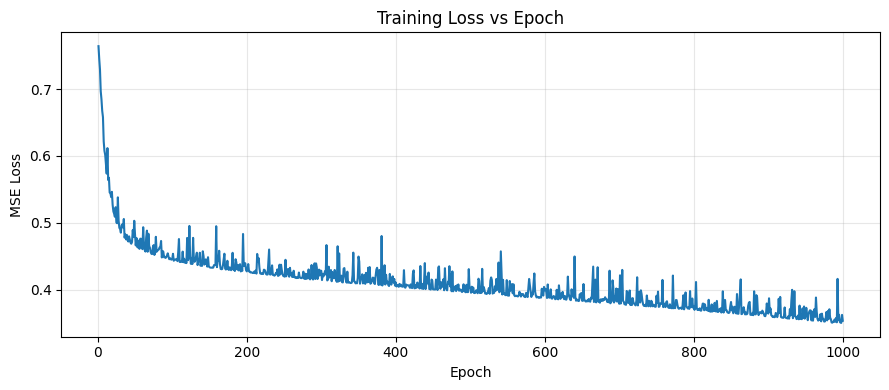

In [15]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, num_epochs + 1), loss_history)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The training loss curve shows how the average MSE (on the standardized targets) changes across epochs. A general downward trend indicates that the model is learning. Some fluctuation is normal with stochastic gradient descent and small batch sizes.

---
## 11. Model Evaluation

We switch the model to evaluation mode and generate predictions on the held-out test set using `torch.no_grad()` to disable gradient computation (which is unnecessary during inference).

In [16]:
model.eval()

with torch.no_grad():
    X_test_dev = X_test_tensor.to(device)
    y_pred_scaled = model(X_test_dev)

# Inverse-transform predictions back to original Diabetes target units
y_pred = target_scaler.inverse_transform(y_pred_scaled.cpu().numpy())
y_actual = y_test  # y_test was never scaled

# Calculate evaluation metrics in original units
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print("=== Test Set Evaluation ===")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R\u00b2   : {r2:.4f}")

=== Test Set Evaluation ===
MSE  : 2668.8358
RMSE : 51.6608
MAE  : 40.5167
R²   : 0.4963


### Interpreting the Metrics

- **MSE (Mean Squared Error)** — the average of squared prediction errors. Lower is better.
- **RMSE (Root Mean Squared Error)** — the square root of MSE, expressed in the same units as the target. It gives a sense of typical prediction error magnitude.
- **MAE (Mean Absolute Error)** — the average absolute difference between predicted and actual values. Less sensitive to outliers than MSE.
- **R² (Coefficient of Determination)** — the proportion of variance in the target that is explained by the model. A value of 1.0 means perfect prediction; a value near 0 means the model does little better than predicting the mean.

---
## 12. Actual vs Predicted Visualization

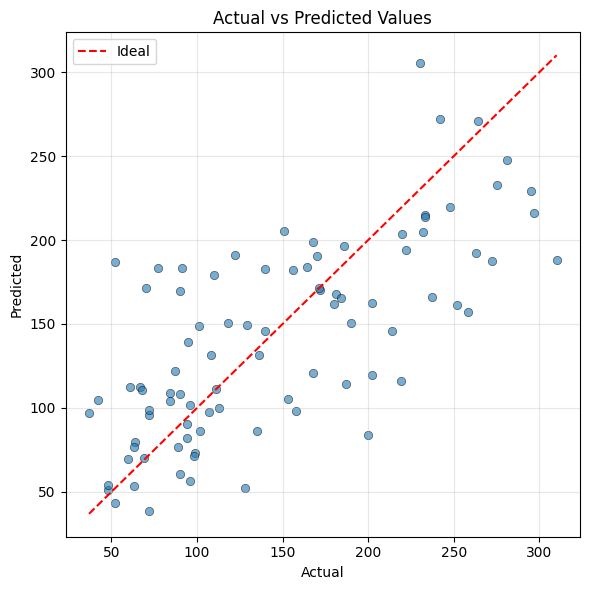

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_actual, y_pred, alpha=0.6, edgecolors="k", linewidth=0.5)

# Reference diagonal (ideal predictions)
min_val = min(y_actual.min(), y_pred.min())
max_val = max(y_actual.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Ideal")

plt.title("Actual vs Predicted Values")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Points close to the red dashed line represent accurate predictions. Points farther from the line indicate larger prediction errors.

---
## 13. Sample Predictions

In [18]:
# Display a sample of test predictions
sample_df = pd.DataFrame({
    "Actual": y_actual.flatten()[:15],
    "Predicted": y_pred.flatten()[:15],
    "Absolute Error": np.abs(y_actual.flatten()[:15] - y_pred.flatten()[:15])
})
sample_df.index.name = "Sample"
sample_df.round(2)

,Actual,Predicted,Absolute Error
Sample,,,
0,219.0,116.050003,102.95
1,70.0,171.669998,101.67
2,202.0,162.460007,39.54
3,230.0,305.179993,75.18
4,111.0,111.230003,0.23
5,84.0,108.860001,24.86
6,242.0,271.989990,29.99
7,272.0,187.600006,84.40
8,94.0,82.199997,11.80


---
## Conclusion

This notebook implemented a regression model using PyTorch while following the main requirements of the laboratory activity: two fully connected layers, MSE loss, a batch size of 8, the SGD optimizer, and 1000 training epochs.

**Tensors** were used to represent the numerical data in a format suitable for PyTorch. `TensorDataset` paired every input vector with its target value, while `DataLoader` organized the training data into shuffled mini-batches of 8. The target was reshaped to `(n, 1)` specifically so that its dimensions matched the model's `(batch_size, 1)` output.

The model consisted of **two fully connected layers** with a ReLU activation between them. Because ReLU introduces non-linearity, the complete model is more accurately described as a small **feedforward neural-network regressor** rather than ordinary linear regression. The first layer maps the 10 input features to 32 hidden units, and the second layer produces one continuous prediction. This architecture contains **385 trainable parameters**.

**MSE Loss** was used to measure squared prediction error, while **SGD** with a learning rate of `0.0001` and momentum of `0.9` updated the parameters during training. Both the features and the training target were standardized using statistics fitted only from the training set. Target standardization was used to improve optimization stability and convergence behavior; it is helpful for this setup but is not a universal requirement for regression. Before evaluation, the predicted target values were inverse-transformed back to the original Diabetes target scale.

On the held-out test set, an R² value around `0.50` means that the model explains roughly half of the variation in the target values relative to a mean-prediction baseline; it should not be interpreted as 50% accuracy. An RMSE around `52` indicates that the model's prediction errors are typically on the order of several dozen units on the Diabetes progression scale. Overall, the model shows moderate predictive ability while leaving substantial variation unexplained.

Possible improvements could include tuning the learning rate and momentum, comparing optimizers, examining regularization, analyzing the input features, or testing alternative model architectures. However, increasing network complexity does not automatically guarantee better performance, especially with a relatively small tabular dataset, because a larger model may also overfit.